***
# Notes
***

1. still need to bring in lag price feature
2. hyper tuning has got from 70% to >90% accuracy
    - `max_depth` is higher than usual; need justification for this
    - `learning_rate` is high (supposedly) aswell
    - still an issue around predicting 0 values (see `Actual v Predicted graph`) 

***

In [1]:
import dataset # local import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seed = 123
df = dataset.read_agg(month_start=1, month_end=12)
print(df.info())
print(df.head(3))

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:297: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:298: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5128903 entries, 0 to 5128902
Data columns (total 22 columns):
 #   Column            Dtype         
---  ------            -----         
 0   pickup_month      int32         
 1   pickup_week       UInt32        
 2   pickup_date       datetime64[ns]
 3   pickup_dow        int32         
 4   time_of_day       object        
 5   pickup_zone       object        
 6   dropoff_zone      object        
 7   route             object        
 8   total_ride_count  int64         
 9   avg_fare_amount   float64       
 10  temp_high         int64         
 11  precip            float64       
 12  snow              float64       
 13  max_wind_speed    float64       
 14  cloud_coverage    float64       
 15  fog               bool          
 16  low_vis           bool          
 17  thunder           bool          
 18  hail              bool          
 19  freezing_rain     bool          
 20  haze              boo

# Preprocess

In [2]:
import pandas as pd

# No need for categorical ordering or complex sorting
daily = df.groupby(['pickup_date', 'time_of_day', 'route'], as_index=False)['total_ride_count'].sum()

# Sort by date to ensure proper shift across days
daily = daily.sort_values(['route', 'time_of_day', 'pickup_date'])

# Lag: same time_of_day, previous day
daily['lag_demand'] = daily.groupby(['route', 'time_of_day'])['total_ride_count'].shift(1)

# Check result
daily[daily['route'] == "Upper East Side North to Upper East Side South"]
df = df.merge(
    daily[['route', 'pickup_date', 'time_of_day', 'lag_demand']],
    on=['time_of_day', 'route', 'pickup_date'],
    how='left'
)
df['lag_demand'] = df['lag_demand'].fillna(0)

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category (just to be sure)
df = df.astype({
    'pickup_zone': 'category',
    'route': 'category',
    'time_of_day': 'category',
    'hail': 'bool',  
    'freezing_rain': 'bool',  
    'holiday': 'category',
})

# Remove waste columns
df = df.drop(errors='ignore', columns=[
    'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',  
    'avg_fare_amount',        
    'hail',
    'freezing_rain',
    'haze',
])

# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    'pickup_dow',
    'time_of_day',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'route',
    'holiday',
]

# Split `y` BEFORE pipeline
# scaler = StandardScaler()
# y = scaler.fit_transform(df['total_ride_count'].values.reshape(-1, 1))
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# scaler_lag = StandardScaler()
# X['lag_demand'] = scaler_lag.fit_transform(X['lag_demand'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

# Train

In [4]:
from xgboost import XGBRegressor
# Comments sourced from: <https://xgboost.readthedocs.io/en/stable/parameter.html>

# Fine-tuning workflow:
#
# 1. max_depth increased from 6 -> 10 and n_estimators increased from 
# 2. set reg_lambda=2; to penalise overreliance on routes & zones  [NO EFFECT]
# 3. set reg_alpha=1; to reduce importance of unimportant features [NO EFFECT]
# 4. set min_child_weight=2; trying to kill weird cluster near 0 values [NO EFFECT]
# 5. set scale_pos_weight=3 [NEGATIVE EFFECT]
# 6. set eval_metric="mae" instead of mean squared err [NO EFFECT]
xg = XGBRegressor(
    n_jobs=1,
    n_estimators=200,
    learning_rate=0.01,

    # Maximum depth of a tree. Increasing this value will make the model more complex 
    # and more likely to overfit. 0 indicates no limit on depth. 
    #
    # Beware that XGBoost aggressively consumes memory when training a deep tree.
    max_depth=18,

    # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, 
    # the more conservative the algorithm will be. 
    # 
    # Note that a tree where no splits were made might still contain a single terminal node with a non-zero score. 
    min_split_loss=2, # default = 0

    # L2 regularization term on weights. 
    # 
    # Increasing this value will make model more conservative.
    reg_lambda=0, # default = 0

    # L1 regularization term on weights. 
    # 
    # Increasing this value will make model more conservative.
    reg_alpha=0, # default = 0

    # Control the balance of positive and negative weights, useful for unbalanced classes. 
    # 
    # A typical value to consider: sum(negative instances) / sum(positive instances).
    scale_pos_weight=2, # default = 1

    # Minimum sum of instance weight (hessian) needed in a child. If the tree partition 
    # step results in a leaf node with the sum of instance weight less than min_child_weight, 
    # then the building process will give up further partitioning. 
    # 
    # In linear regression task, this simply corresponds to minimum number of instances 
    # needed to be in each node. 
    # 
    # The larger min_child_weight is, the more conservative the algorithm will be.
    min_child_weight=0, # default = 1

    # Evaluation metrics for validation data, a default metric will be assigned 
    # according to objective (rmse for regression, and logloss for classification, 
    # mean average precision for rank:map, etc.)
    eval_metric="rmse", # default = "rmse"
    random_state=seed
)

xg.fit(
    X_train, y_train,

    # If model fails to improve on the validation set for 50 rounds, just stop
    # early_stopping_rounds=50, 
    # eval_set=[(X_val, y_val)],

    # Print report on training process
    # verbose=100,    
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


Mean Absolute Error: 	2.2726
Mean Squared Error: 	19.7480
R squared: 		0.8816


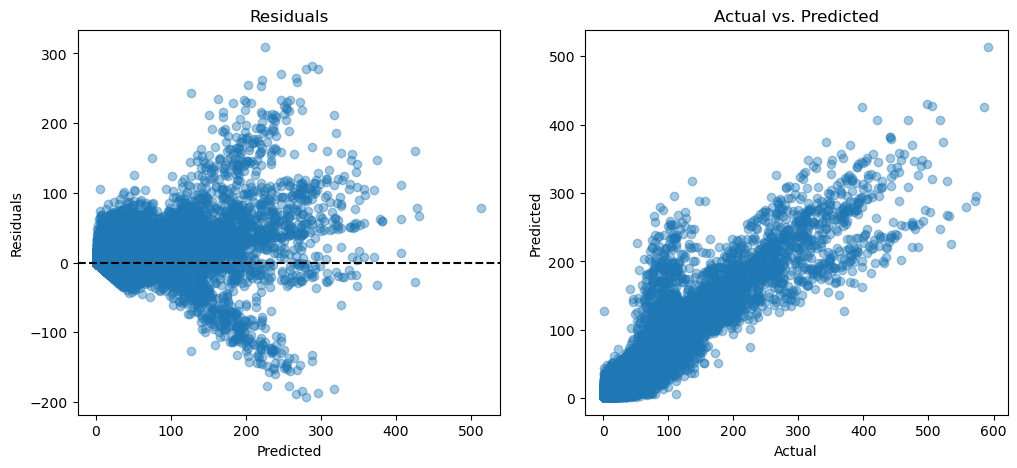

In [5]:
import helpers

training_predictions = xg.predict(X_train)
helpers.analysis(y_train, training_predictions)

Mean Absolute Error: 	2.4923
Mean Squared Error: 	28.7925
R squared: 		0.8252


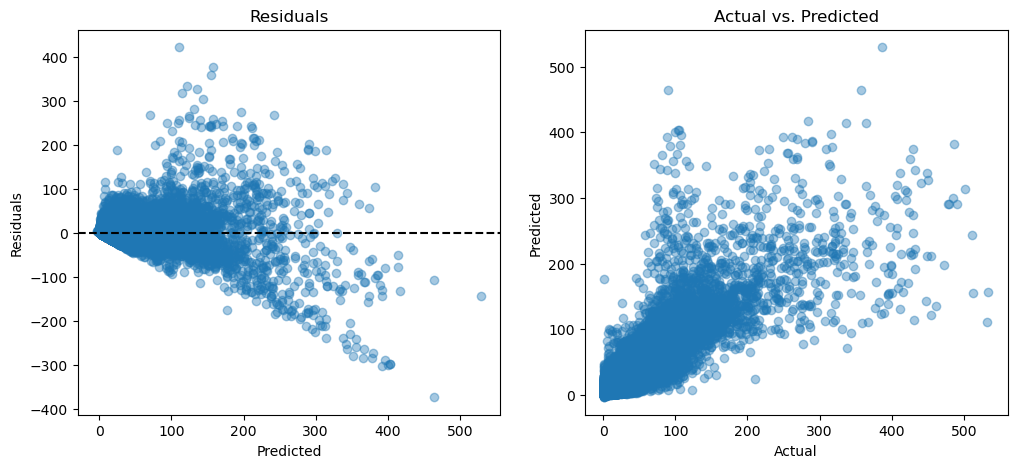

In [ ]:
validation_predictions = xg.predict(X_val)
helpers.analysis(y_val, validation_predictions)

                      feature  importance
20      remainder__lag_demand    0.396230
6        onehot__pickup_dow_6    0.106090
18         remainder__low_vis    0.080371
5        onehot__pickup_dow_5    0.066641
10       ordinal__time_of_day    0.036888
0        onehot__pickup_dow_0    0.036321
8              ordinal__route    0.028491
14            remainder__snow    0.026788
9            ordinal__holiday    0.025740
1        onehot__pickup_dow_1    0.023738
19         remainder__thunder    0.020990
4        onehot__pickup_dow_4    0.019789
17             remainder__fog    0.017710
7        ordinal__pickup_zone    0.016892
13          remainder__precip    0.016323
12       remainder__temp_high    0.015524
15  remainder__max_wind_speed    0.015230
16  remainder__cloud_coverage    0.015001
11    remainder__pickup_month    0.013165
3        onehot__pickup_dow_3    0.012051
2        onehot__pickup_dow_2    0.010026


<Figure size 1200x1200 with 0 Axes>

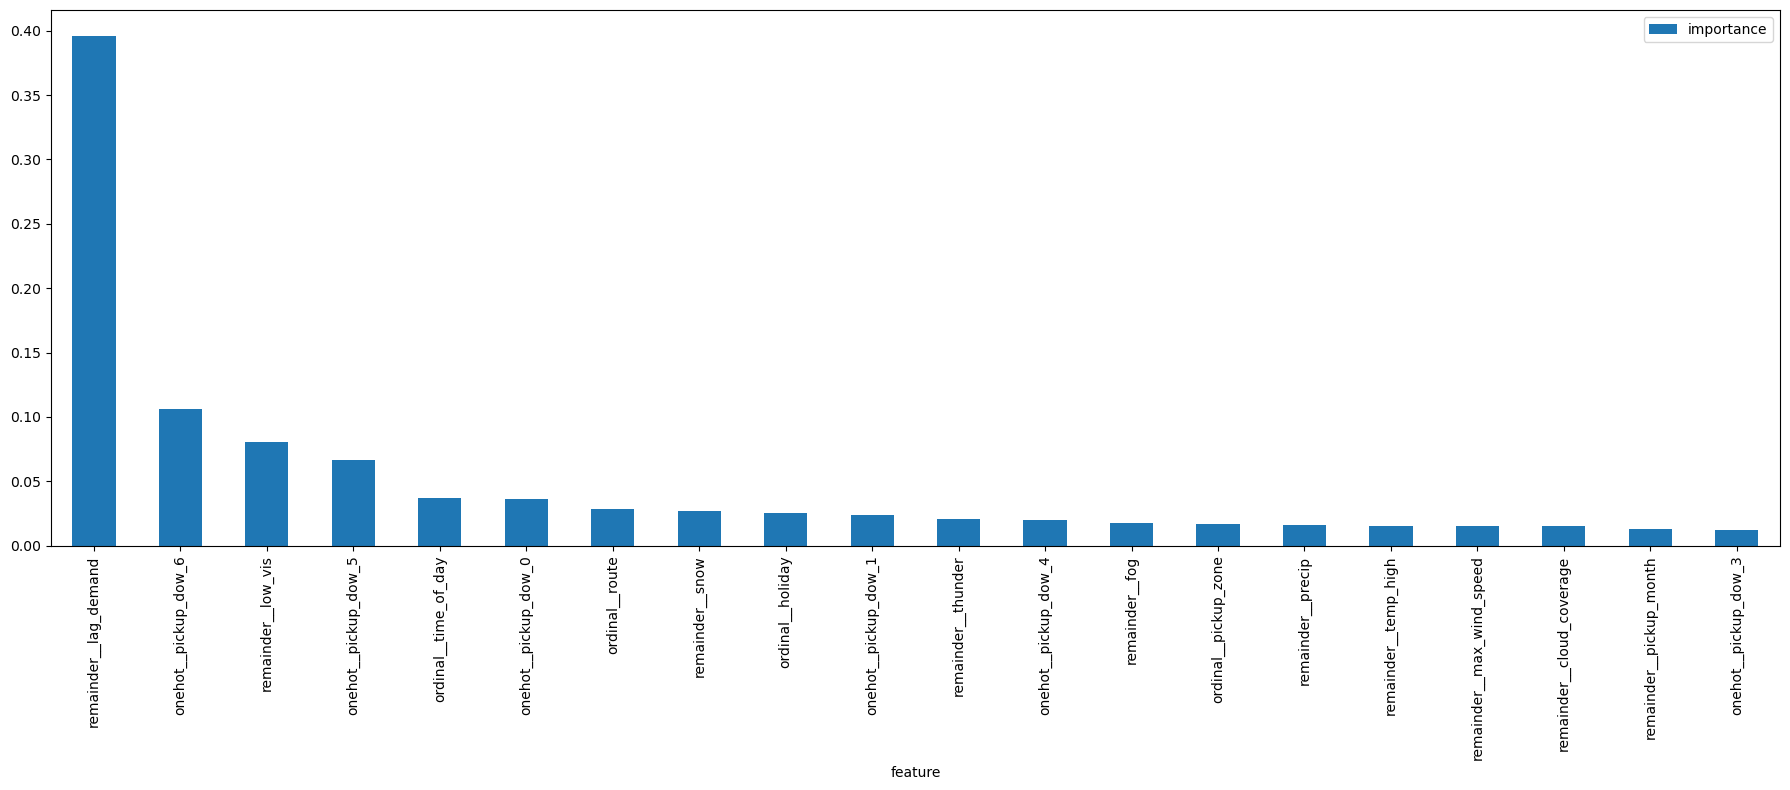

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = pipeline.get_feature_names_out()
importances = xg.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feat_df)

plt.figure(figsize=(12,12))
feat_df.head(20).plot(kind='bar', x='feature', y='importance', figsize=(18, 8))
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# Test

Mean Absolute Error: 	2.5123
Mean Squared Error: 	30.5582
R squared: 		0.8147


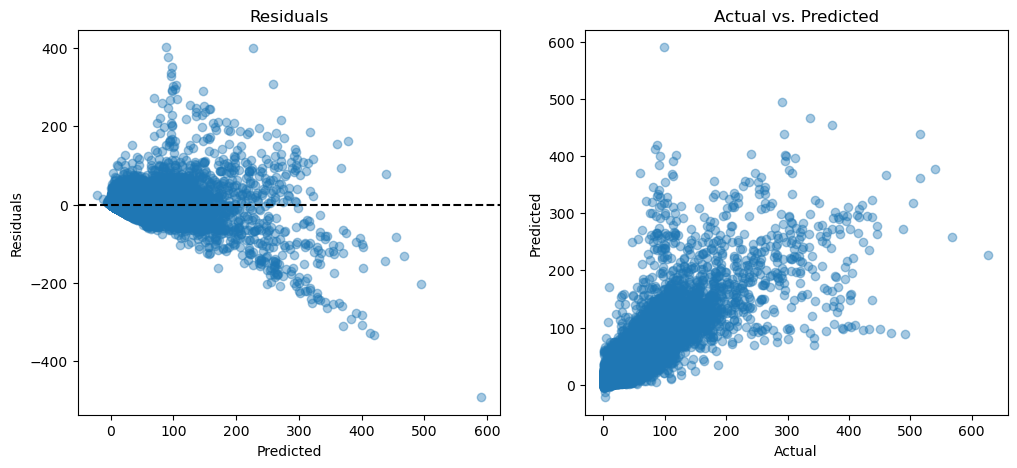

In [ ]:
test_predictions = xg.predict(X_test)
helpers.analysis(y_test, test_predictions)